# EDA — synthetic_injection_molding_dataset.csv

Goal: understand the shape, quality and target behaviour of this dataset, and check whether it can replace/augment `injection_molding_predictive_maintenance.csv` for the predictive-maintenance modelling work in `maintenance_model_building.ipynb`.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

## 1. Load & basic shape

In [2]:
df = pd.read_csv('synthetic_injection_molding.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])
print(df.shape)
df.head()

(40000, 46)


,mold_name,timestamp,material_name,machine_tonnage,cycle_number,hopper_temp,nozzle_temp,H1,H2,H3,mold_core_temp,mold_cavity_temp,inj_speed1,inj_speed2,inj_speed3,actual_inj_pressure,vp_transition,inj_time_actual,holding_pressure_stage1,holding_pressure_stage2,holding_pressure_stage3,screw_rpm,back_pressure,decompression_speed,decompression_distance,cushion_size,clamp_force,mold_close_speed,mold_protection_pressure,ejection_stroke,ejection_speed,cooling_time,mold_open_reset_time,part_weight,shot_weight,screw_diameter,total_cycle_time,Hopper_State,Barrel_Heater_State,Screw_State,Injection_Unit_State,Hydraulic_System_State,Clamp_Unit_State,Mold_State,Cooling_System_State,Ejector_System_State
0,Smart Router Enclosure (Top Cover) (TL-2026-AB...,2024-01-01 06:00:00.000000,"ABS (Flame Retardant, Medium Flow)",180,1,45,230,225,211,201,67,70,34,57,19,120,8.9,1.33,76,53,34,76,8,14,4.8,4.0,134,248,12,48,38,14.66,3.67,34.4,86.1,45,24.61,0,0,0,0,0,0,0,0,0
1,Smart Router Enclosure (Top Cover) (TL-2026-AB...,2024-01-01 06:00:24.614608,"ABS (Flame Retardant, Medium Flow)",180,2,44,231,225,216,198,65,72,34,55,20,119,8.5,1.38,74,52,34,75,8,16,5.1,3.8,133,248,12,47,39,14.07,3.69,34.0,85.3,45,24.13,0,0,0,0,0,0,0,0,0
2,Smart Router Enclosure (Top Cover) (TL-2026-AB...,2024-01-01 06:00:48.747552,"ABS (Flame Retardant, Medium Flow)",180,3,45,229,225,215,200,65,71,35,58,20,121,8.6,1.37,73,54,34,76,8,14,4.9,4.1,133,236,12,46,38,14.57,3.59,34.9,82.9,45,24.49,0,0,0,0,0,0,0,0,0
3,Smart Router Enclosure (Top Cover) (TL-2026-AB...,2024-01-01 06:01:13.233168,"ABS (Flame Retardant, Medium Flow)",180,4,45,230,224,214,203,65,71,35,60,18,118,8.6,1.34,76,56,35,74,8,15,5.2,4.0,140,241,11,47,39,14.26,3.41,33.5,84.2,45,24.06,0,0,0,0,0,0,0,0,0
4,Smart Router Enclosure (Top Cover) (TL-2026-AB...,2024-01-01 06:01:37.295439,"ABS (Flame Retardant, Medium Flow)",180,5,45,230,224,215,202,65,69,34,58,19,117,9.0,1.35,76,53,35,74,8,14,4.8,4.1,138,253,11,43,39,13.96,3.44,33.5,79.8,45,23.63,0,0,0,0,0,0,0,0,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 46 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   mold_name                 40000 non-null  str           
 1   timestamp                 40000 non-null  datetime64[us]
 2   material_name             40000 non-null  str           
 3   machine_tonnage           40000 non-null  int64         
 4   cycle_number              40000 non-null  int64         
 5   hopper_temp               40000 non-null  int64         
 6   nozzle_temp               40000 non-null  int64         
 7   H1                        40000 non-null  int64         
 8   H2                        40000 non-null  int64         
 9   H3                        40000 non-null  int64         
 10  mold_core_temp            40000 non-null  int64         
 11  mold_cavity_temp          40000 non-null  int64         
 12  inj_speed1                400

In [4]:
target = ['Hopper_State','Barrel_Heater_State', 'Screw_State', 'Injection_Unit_State','Hydraulic_System_State',
          'Clamp_Unit_State', 'Mold_State','Cooling_System_State', 'Ejector_System_State']
id_cols = ['mold_name', 'timestamp', 'material_name']
sensor = [c for c in df.columns if c not in target + id_cols]
print(f'{len(sensor)} sensor/process columns, {len(target)} target (component-state) columns')
sensor

34 sensor/process columns, 9 target (component-state) columns


['machine_tonnage',
 'cycle_number',
 'hopper_temp',
 'nozzle_temp',
 'H1',
 'H2',
 'H3',
 'mold_core_temp',
 'mold_cavity_temp',
 'inj_speed1',
 'inj_speed2',
 'inj_speed3',
 'actual_inj_pressure',
 'vp_transition',
 'inj_time_actual',
 'holding_pressure_stage1',
 'holding_pressure_stage2',
 'holding_pressure_stage3',
 'screw_rpm',
 'back_pressure',
 'decompression_speed',
 'decompression_distance',
 'cushion_size',
 'clamp_force',
 'mold_close_speed',
 'mold_protection_pressure',
 'ejection_stroke',
 'ejection_speed',
 'cooling_time',
 'mold_open_reset_time',
 'part_weight',
 'shot_weight',
 'screw_diameter',
 'total_cycle_time']

## 2. Missing values & duplicates

In [5]:
print('Missing values per column:')
print(df.isna().sum()[df.isna().sum() > 0])
print('\nTotal missing cells:', df.isna().sum().sum())
print('Fully duplicated rows:', df.duplicated().sum())

Missing values per column:
Series([], dtype: int64)

Total missing cells: 0
Fully duplicated rows: 0


No nulls and no duplicate rows — the file is clean to load directly, unlike raw sensor logs which usually need imputation.

## 3. Molds, materials & time coverage

Note: this file has **no `mold_id` column** (only `mold_name`), unlike `injection_molding_predictive_maintenance.csv`. That matters for the existing pipeline, which one-hot-encodes `mold_id` and sorts by `['mold_id', 'cycle_number']` for the train/val/test split.

In [6]:
print('Unique molds:', df['mold_name'].nunique())
print('Unique materials:', df['material_name'].nunique())
print()
print(df.groupby('mold_name').size())
print()
print('One material per mold?', (df.groupby('mold_name')['material_name'].nunique() == 1).all())

Unique molds: 4
Unique materials: 4

mold_name
500ml Rectangular Food Container (PKG-TW-04-992)              10000
Clear Blood Filtration Housing (MED-PC-4001)                  10000
Engine Mount Bracket (Structural Core) (AUTO-BRK-1Cav-45A)    10000
Smart Router Enclosure (Top Cover) (TL-2026-ABS-0892)         10000
dtype: int64

One material per mold? True


In [7]:
df.groupby('mold_name')['timestamp'].agg(['min', 'max', 'count'])

,min,max,count
mold_name,,,
500ml Rectangular Food Container (PKG-TW-04-992),2024-01-08 00:36:36.844168,2024-01-08 13:51:05.369857,10000
Clear Blood Filtration Housing (MED-PC-4001),2024-01-04 05:21:41.103434,2024-01-08 00:35:03.842652,10000
Engine Mount Bracket (Structural Core) (AUTO-BRK-1Cav-45A),2024-01-08 13:52:10.141273,2024-01-13 09:41:58.347305,10000
Smart Router Enclosure (Top Cover) (TL-2026-ABS-0892),2024-01-01 06:00:00.000000,2024-01-04 05:20:15.576980,10000


In [8]:
# cycle_number should be contiguous per mold if this is a clean simulated run
gaps = df.groupby('mold_name')['cycle_number'].apply(lambda s: (s.sort_values().diff().dropna() != 1).sum())
print('Non-consecutive cycle_number jumps per mold:')
print(gaps)

Non-consecutive cycle_number jumps per mold:
mold_name
500ml Rectangular Food Container (PKG-TW-04-992)              0
Clear Blood Filtration Housing (MED-PC-4001)                  0
Engine Mount Bracket (Structural Core) (AUTO-BRK-1Cav-45A)    0
Smart Router Enclosure (Top Cover) (TL-2026-ABS-0892)         0
Name: cycle_number, dtype: int64


Exactly 10,000 cycles for each of the 4 molds (40,000 rows total, perfectly balanced by design), each mapped 1:1 to a single material, and `cycle_number` is contiguous — this is a clean, evenly-simulated dataset rather than an organic production log.

## 4. Sensor / process parameter distributions

In [9]:
df[sensor].describe().T

,count,mean,std,min,25%,50%,75%,max
machine_tonnage,40000.0,282.500000,80.118103,180.00,232.5000,275.000,325.0000,400.00
cycle_number,40000.0,5000.500000,2886.787417,1.00,2500.7500,5000.500,7500.2500,10000.00
hopper_temp,40000.0,46.036250,9.244616,27.00,36.0000,46.000,54.0000,66.00
nozzle_temp,40000.0,260.923675,27.554740,221.00,233.0000,261.000,288.0000,293.00
H1,40000.0,256.888150,26.901231,214.00,229.0000,258.500,283.0000,288.00
H2,40000.0,246.436200,28.986350,202.00,216.0000,245.000,275.0000,285.00
H3,40000.0,233.363725,31.483981,184.00,201.0000,231.000,265.0000,275.00
mold_core_temp,40000.0,69.586225,35.416674,12.00,51.0000,80.000,98.0000,124.00
mold_cavity_temp,40000.0,75.700275,37.085925,14.00,55.7500,87.500,106.0000,130.00
inj_speed1,40000.0,125.356525,171.691305,13.00,21.0000,30.000,100.2500,498.00


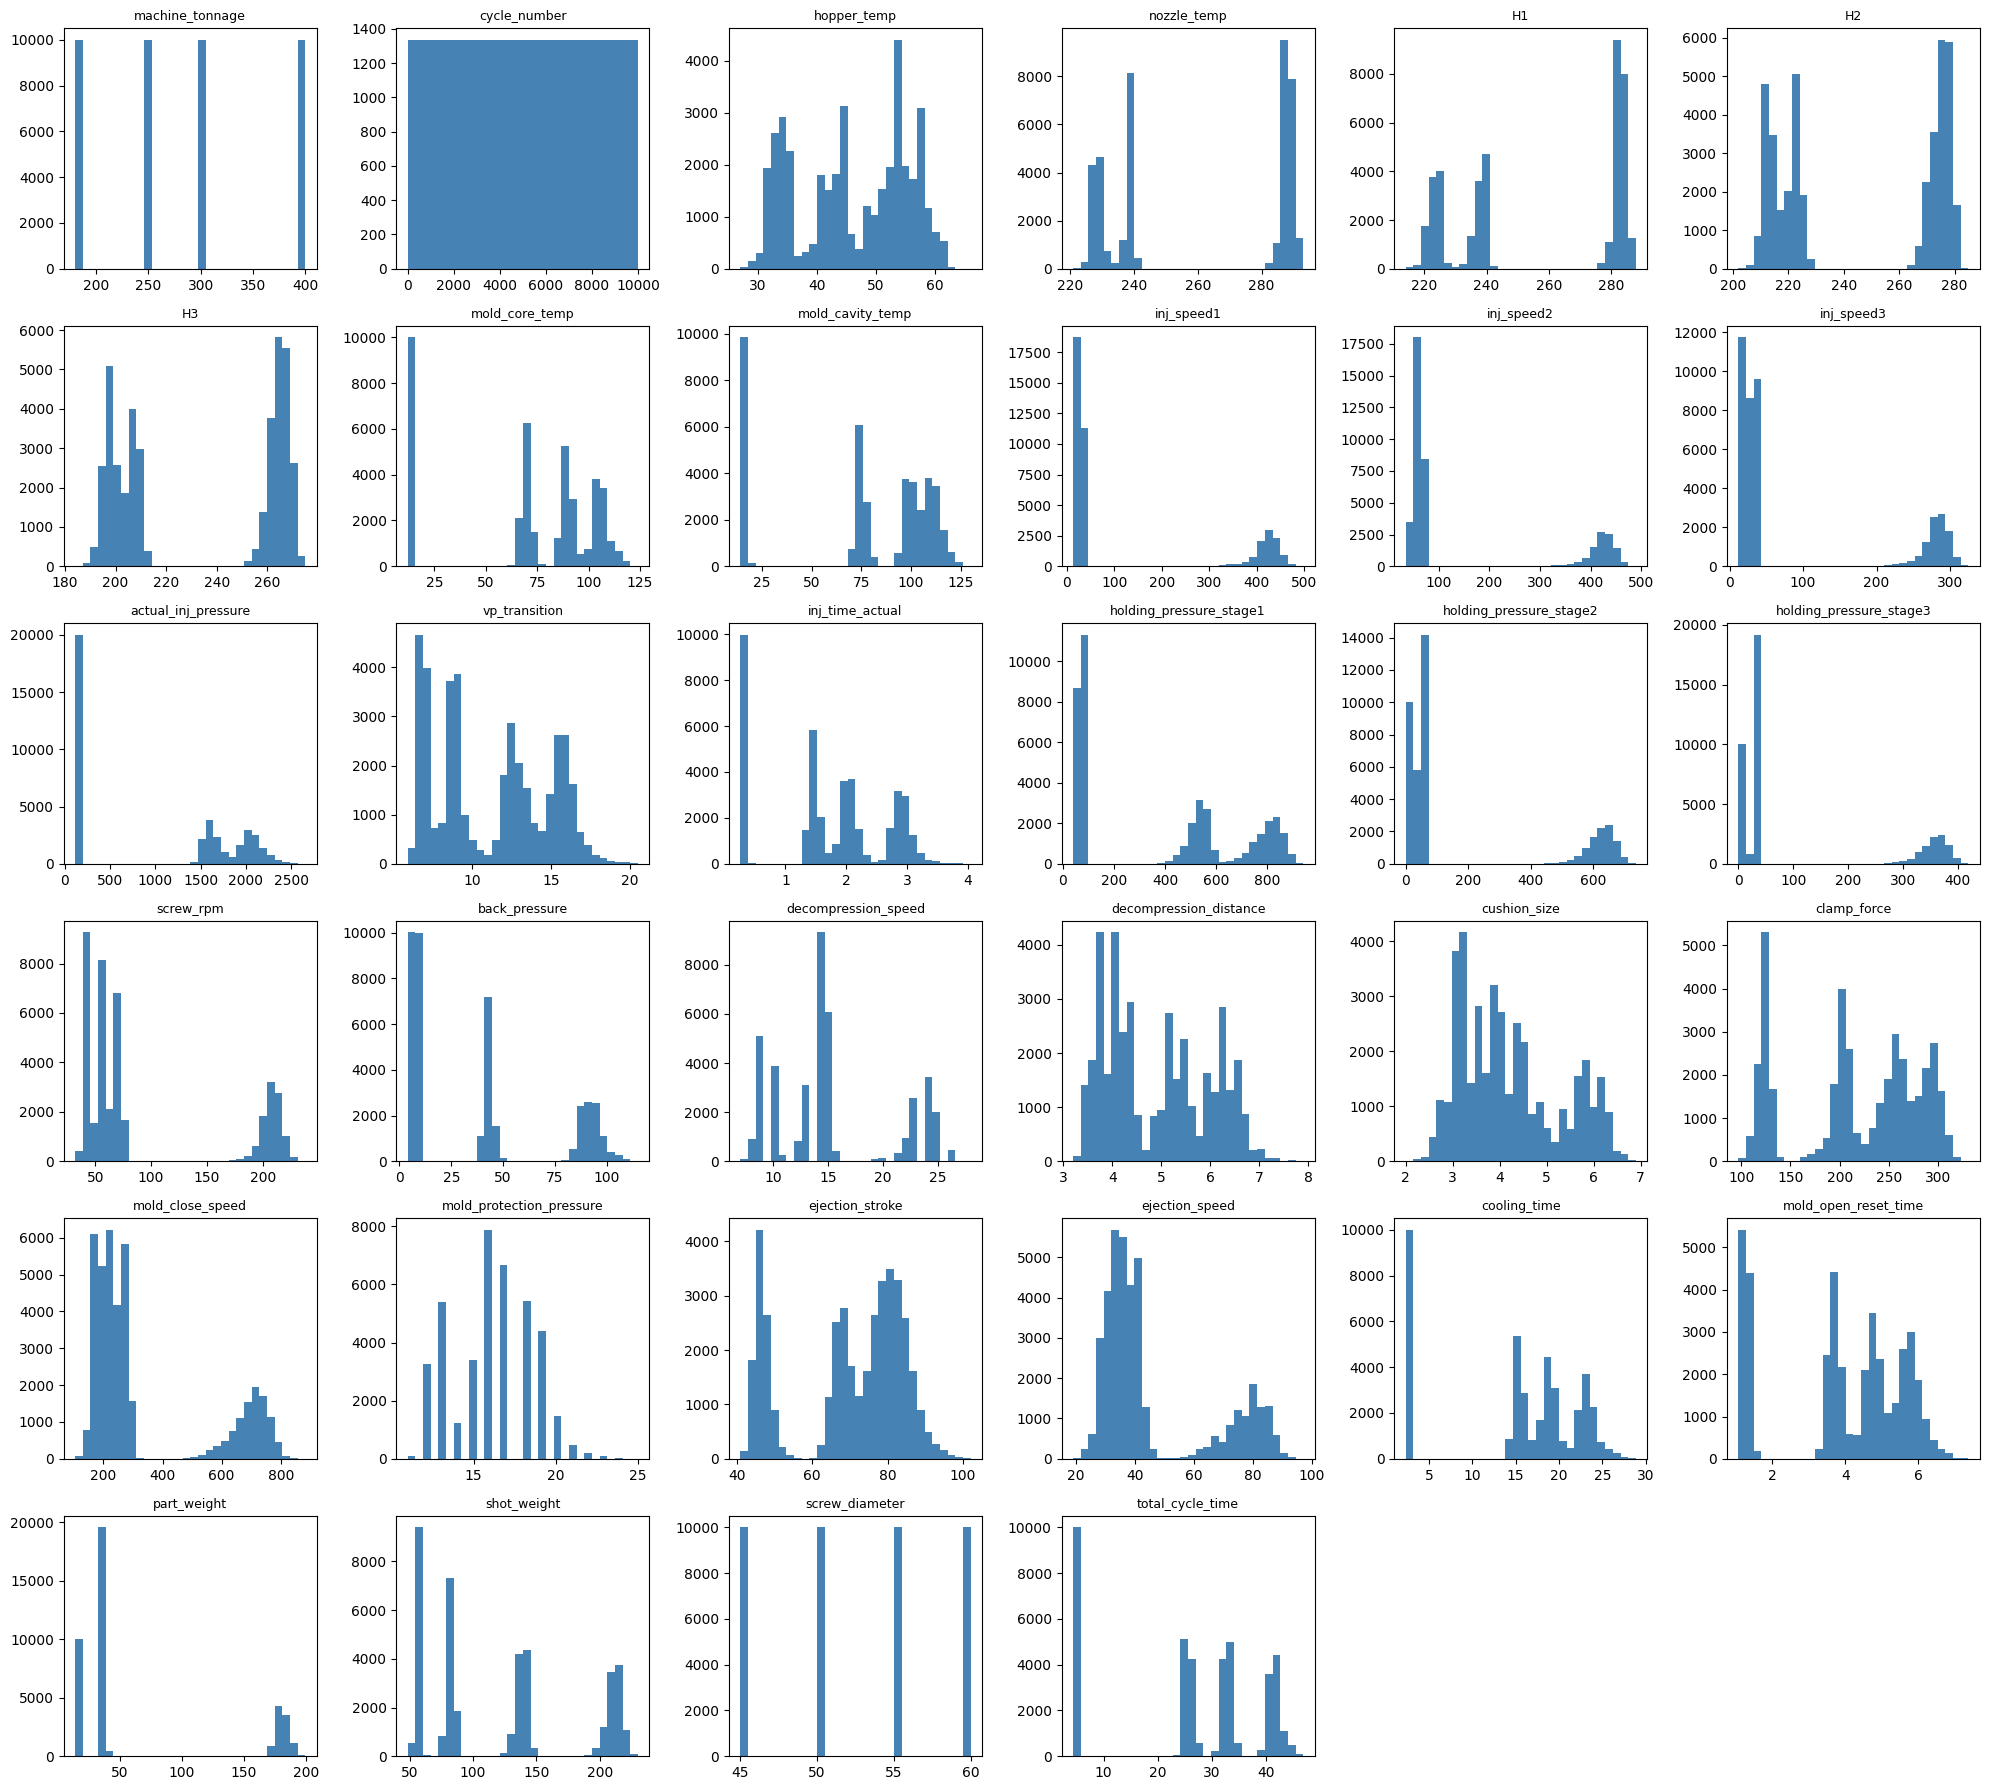

In [10]:
fig, axes = plt.subplots(6, 6, figsize=(20, 18))
for ax, col in zip(axes.flat, sensor):
    ax.hist(df[col], bins=30, color='steelblue')
    ax.set_title(col, fontsize=9)
for ax in axes.flat[len(sensor):]:
    ax.axis('off')
plt.tight_layout()
plt.show()

## 5. Target (component-state) columns

Each of the 9 targets is 3-class: `0 = healthy`, `1 = warning`, `2 = fault` (consistent with the old dataset's encoding used in `maintenance_model_building.ipynb`).

In [11]:
state_counts = df[target].apply(lambda s: s.value_counts(normalize=True)).T.fillna(0)
state_counts.columns = ['healthy (0)', 'warning (1)', 'fault (2)']
state_counts.round(3)

,healthy (0),warning (1),fault (2)
Hopper_State,0.749,0.214,0.037
Barrel_Heater_State,0.817,0.156,0.027
Screw_State,0.820,0.150,0.030
Injection_Unit_State,0.820,0.141,0.040
Hydraulic_System_State,0.830,0.130,0.040
Clamp_Unit_State,0.841,0.130,0.029
Mold_State,0.799,0.175,0.026
Cooling_System_State,0.813,0.142,0.045
Ejector_System_State,0.785,0.171,0.044


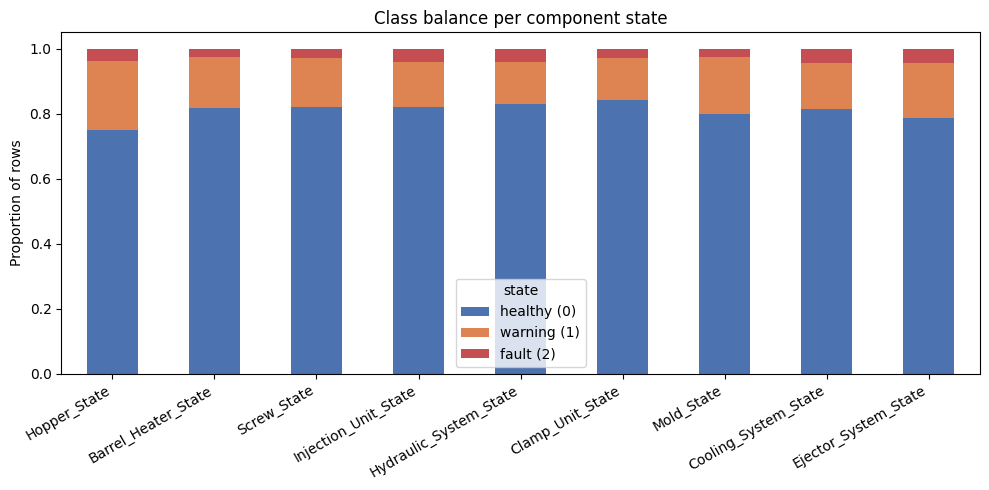

In [12]:
state_counts.plot(kind='bar', stacked=True, figsize=(10, 5), color=['#4C72B0', '#DD8452', '#C44E52'])
plt.ylabel('Proportion of rows')
plt.title('Class balance per component state')
plt.xticks(rotation=30, ha='right')
plt.legend(title='state')
plt.tight_layout()
plt.show()

0     6262
1    12516
2    11086
3     6960
4     2448
5      656
6       72
Name: count, dtype: int64

Fully healthy rows (all 9 states = 0): 6262 (15.7%)
Rows with >=1 abnormal component: 33738 (84.3%)


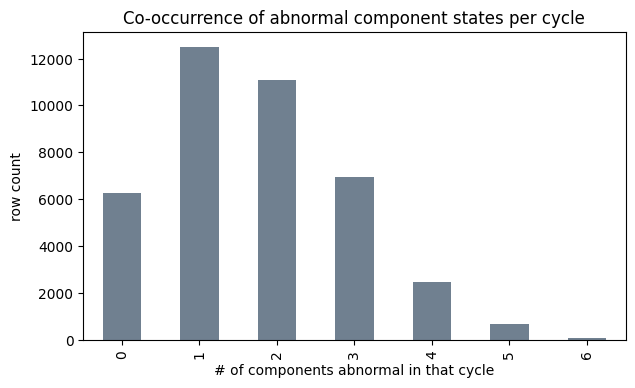

In [13]:
n_abnormal = (df[target] != 0).sum(axis=1)
print(n_abnormal.value_counts().sort_index())
print()
print('Fully healthy rows (all 9 states = 0):', (n_abnormal == 0).sum(), f"({(n_abnormal == 0).mean():.1%})")
print('Rows with >=1 abnormal component:', (n_abnormal > 0).sum(), f"({(n_abnormal > 0).mean():.1%})")

n_abnormal.value_counts().sort_index().plot(kind='bar', figsize=(7, 4), color='slategray')
plt.xlabel('# of components abnormal in that cycle')
plt.ylabel('row count')
plt.title('Co-occurrence of abnormal component states per cycle')
plt.show()

Only ~15-16% of rows are fully healthy across all 9 components — much lower than in the old dataset. That shrinks the `X_train_healthy` set the current novelty-detection approach (Isolation Forest / ECOD / COPOD / LOF / Autoencoder, all fit on healthy-only rows) relies on. Confirm this against the old file below.

In [14]:
import os

print(f'New dataset:  {len(df):,} rows, fully-healthy = {(n_abnormal == 0).mean():.1%}')

old_path = 'injection_molding_predictive_maintenance.csv'
if os.path.exists(old_path):
    old = pd.read_csv(old_path, usecols=target)
    old_healthy = (old == 0).all(axis=1)
    print(f'Old dataset:  {len(old):,} rows, fully-healthy = {old_healthy.mean():.1%}')
else:
    # File isn't present in the workspace anymore; recorded from the last time this
    # notebook was run against it, for reference.
    print(f"Old dataset:  '{old_path}' not found in workspace — last recorded fully-healthy rate = 27.8% (40,000 rows)")

New dataset:  40,000 rows, fully-healthy = 15.7%
Old dataset:  'injection_molding_predictive_maintenance.csv' not found in workspace — last recorded fully-healthy rate = 27.8% (40,000 rows)


## 6. Correlation among sensor features

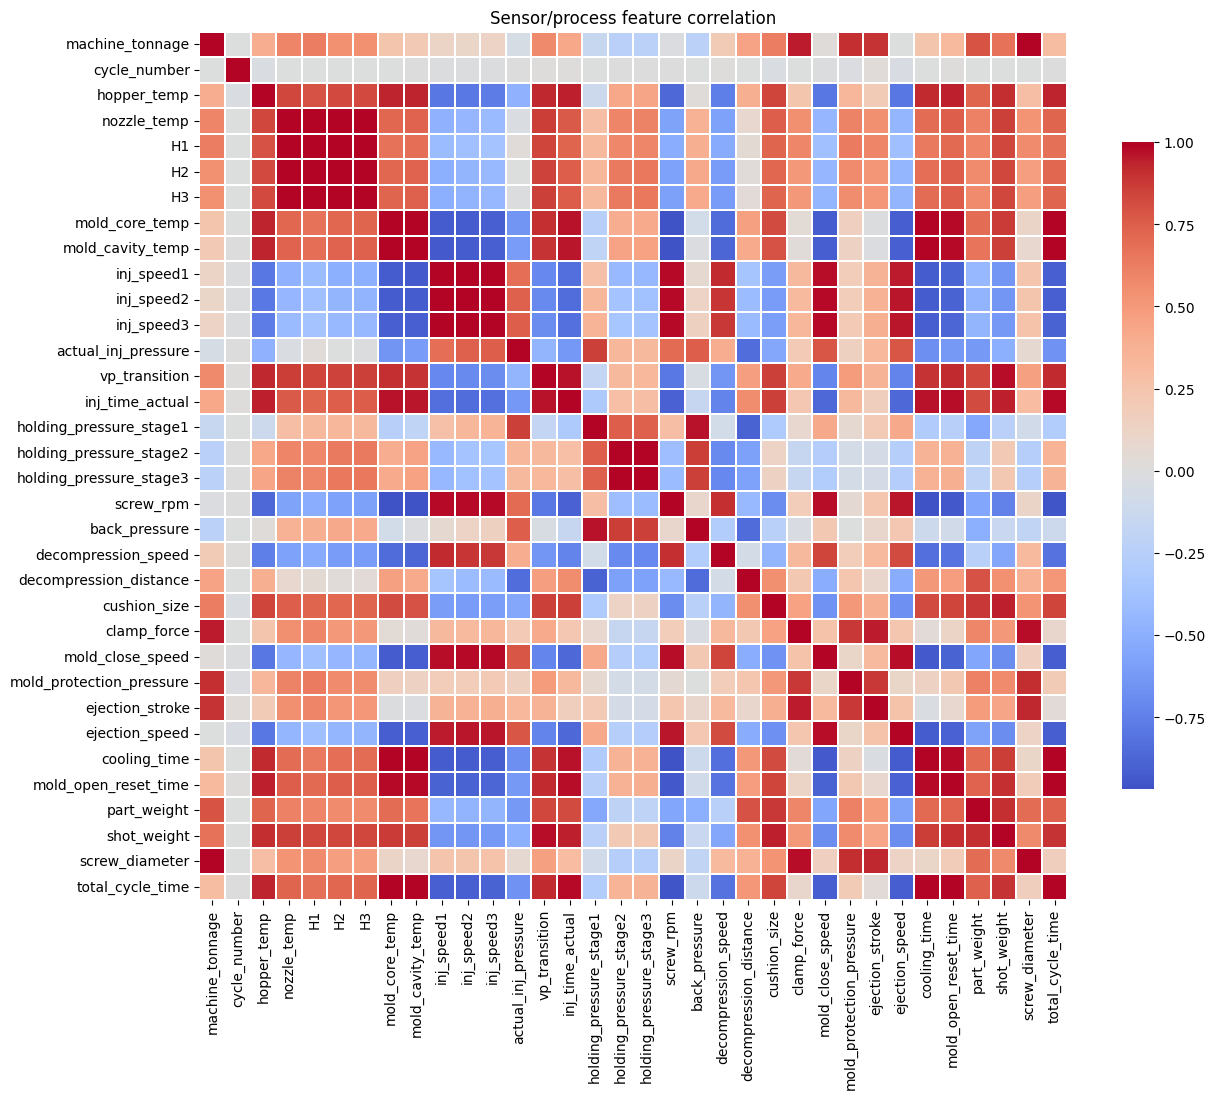

In [15]:
corr = df[sensor].corr()
plt.figure(figsize=(14, 12))
sns.heatmap(corr, cmap='coolwarm', center=0, square=True, linewidths=0.3, cbar_kws={'shrink': 0.7})
plt.title('Sensor/process feature correlation')
plt.show()

In [16]:
# Highly correlated pairs (|r| >= 0.9) - candidates to drop before modelling, same idea
# as find_correlation() in maintenance_model_building.ipynb
pairs = (corr.abs()
         .where(np.triu(np.ones(corr.shape), k=1).astype(bool))
         .stack()
         .sort_values(ascending=False))
pairs[pairs >= 0.9]

holding_pressure_stage2  holding_pressure_stage3     0.998567
H2                       H3                          0.997340
cooling_time             total_cycle_time            0.997305
inj_speed2               inj_speed3                  0.997235
mold_core_temp           mold_cavity_temp            0.996991
                                                       ...   
ejection_speed           mold_open_reset_time        0.902563
machine_tonnage          mold_protection_pressure    0.902454
mold_core_temp           vp_transition               0.902378
inj_time_actual          screw_rpm                   0.901571
mold_open_reset_time     shot_weight                 0.900278
Length: 90, dtype: float64

## 7. Do the sensor features actually relate to their matching component state?

Sanity check: `hopper_temp` should move with `Hopper_State`, the `H1/H2/H3` heater zones with `Barrel_Heater_State`, screw-related fields with `Screw_State`, etc. If a target is unrelated to any feature (as `plots.ipynb` already flagged for `screw_rpm` vs `Screw_State`), it's effectively unlearnable from this feature set.

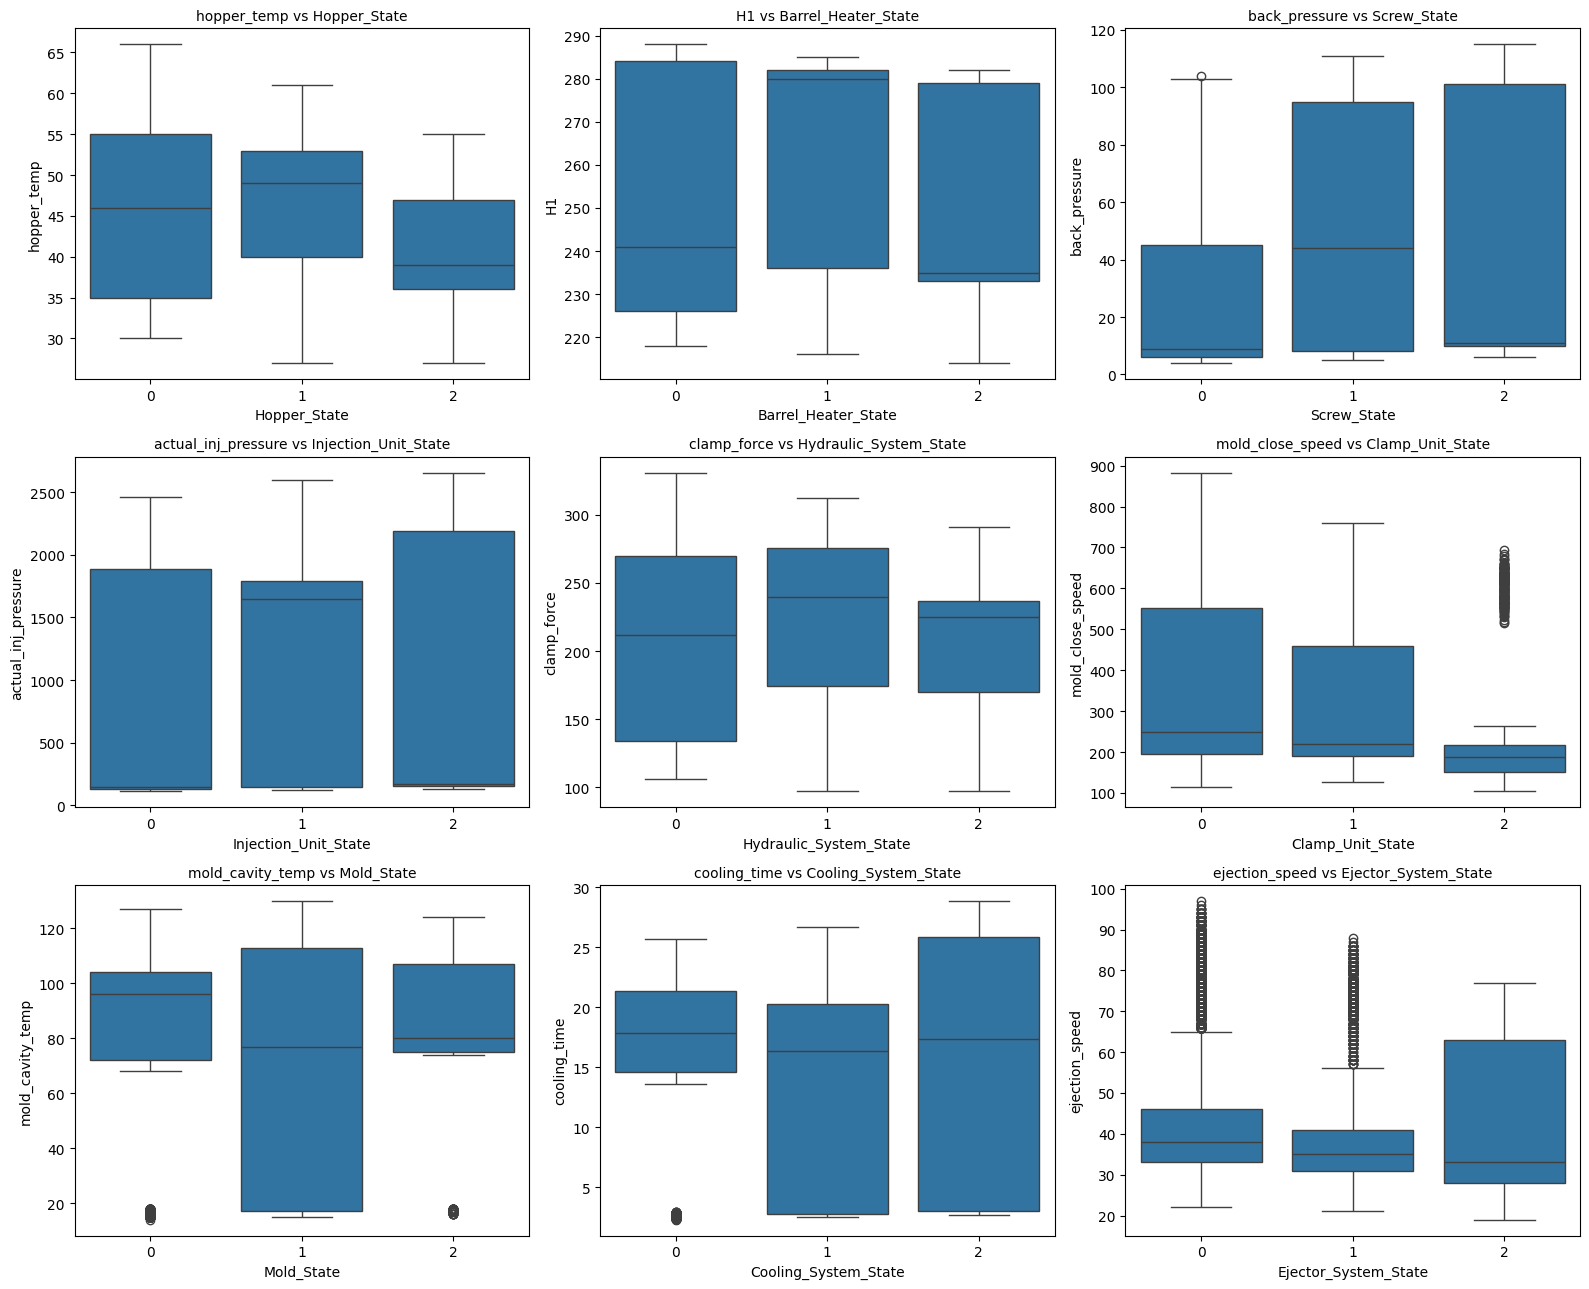

In [17]:
checks = {
    'Hopper_State': 'hopper_temp',
    'Barrel_Heater_State': 'H1',
    'Screw_State': 'back_pressure',
    'Injection_Unit_State': 'actual_inj_pressure',
    'Hydraulic_System_State': 'clamp_force',
    'Clamp_Unit_State': 'mold_close_speed',
    'Mold_State': 'mold_cavity_temp',
    'Cooling_System_State': 'cooling_time',
    'Ejector_System_State': 'ejection_speed',
}

fig, axes = plt.subplots(3, 3, figsize=(16, 13))
for ax, (tgt, feat) in zip(axes.flat, checks.items()):
    sns.boxplot(data=df, x=tgt, y=feat, ax=ax)
    ax.set_title(f'{feat} vs {tgt}', fontsize=10)
plt.tight_layout()
plt.show()

In [18]:
# Quick signal-strength check: shallow RandomForest train accuracy per target using all sensor features.
# Not a real model (no train/test split) - just checks whether the targets carry learnable signal
# at all, and whether the top features make physical sense.
from sklearn.ensemble import RandomForestClassifier

X = df[sensor]
rows = []
for t in target:
    rf = RandomForestClassifier(n_estimators=150, max_depth=6, random_state=42, n_jobs=-1)
    rf.fit(X, df[t])
    top3 = ', '.join(f'{c} ({i:.2f})' for c, i in
                      sorted(zip(sensor, rf.feature_importances_), key=lambda x: -x[1])[:3])
    rows.append({'target': t, 'train_accuracy': round(rf.score(X, df[t]), 3), 'top_features': top3})

pd.DataFrame(rows)

,target,train_accuracy,top_features
0,Hopper_State,0.804,"hopper_temp (0.44), cycle_number (0.13), part_..."
1,Barrel_Heater_State,0.899,"nozzle_temp (0.17), H1 (0.17), H3 (0.15)"
2,Screw_State,0.916,"decompression_distance (0.17), back_pressure (..."
3,Injection_Unit_State,0.921,"inj_speed1 (0.18), inj_speed2 (0.15), vp_trans..."
4,Hydraulic_System_State,0.903,"actual_inj_pressure (0.15), mold_close_speed (..."
5,Clamp_Unit_State,0.888,"mold_protection_pressure (0.24), mold_close_sp..."
6,Mold_State,0.856,"part_weight (0.28), mold_core_temp (0.13), mol..."
7,Cooling_System_State,0.861,"cooling_time (0.27), total_cycle_time (0.20), ..."
8,Ejector_System_State,0.854,"ejection_stroke (0.27), mold_open_reset_time (..."


## 8. Cycle duration vs. health status

Does a cycle take longer (`total_cycle_time`) when a component is unhealthy? Build one overall per-row status from the 9 targets: `healthy` (all 9 = 0), `fault` (any target = 2), otherwise `warning`.

In [19]:
n_abnormal = (df[target] != 0).sum(axis=1)
df['overall_status'] = np.select(
    [n_abnormal == 0, (df[target] == 2).any(axis=1)],
    ['healthy', 'fault'],
    default='warning'
)

df.groupby('overall_status')['total_cycle_time'].describe()

,count,mean,std,min,25%,50%,75%,max
overall_status,,,,,,,,
fault,10850.0,24.869574,14.290104,4.32,4.99,26.71,33.9775,46.91
healthy,6262.0,28.080818,11.832564,4.33,25.07,31.75,39.5000,43.69
warning,22888.0,26.402720,13.760117,4.34,5.13,31.70,40.1200,45.65


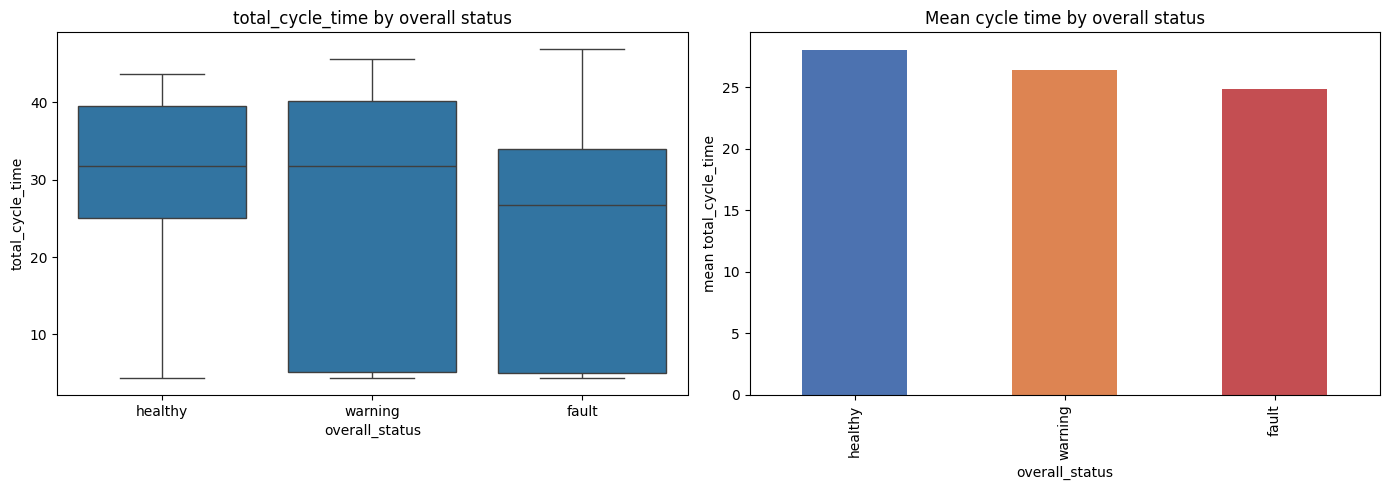

In [20]:
order = ['healthy', 'warning', 'fault']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='overall_status', y='total_cycle_time', order=order, ax=axes[0])
axes[0].set_title('total_cycle_time by overall status')

(df.groupby('overall_status')['total_cycle_time'].mean().reindex(order)
   .plot(kind='bar', ax=axes[1], color=['#4C72B0', '#DD8452', '#C44E52']))
axes[1].set_ylabel('mean total_cycle_time')
axes[1].set_title('Mean cycle time by overall status')
plt.tight_layout()
plt.show()

In [21]:
from scipy.stats import mannwhitneyu

healthy_ct = df.loc[df['overall_status'] == 'healthy', 'total_cycle_time']
unhealthy_ct = df.loc[df['overall_status'] != 'healthy', 'total_cycle_time']

stat, p = mannwhitneyu(healthy_ct, unhealthy_ct)
print(f'Healthy mean total_cycle_time:   {healthy_ct.mean():.2f}s (n={len(healthy_ct)})')
print(f'Unhealthy mean total_cycle_time: {unhealthy_ct.mean():.2f}s (n={len(unhealthy_ct)})')
print(f'Difference (unhealthy - healthy): {unhealthy_ct.mean() - healthy_ct.mean():+.2f}s')
print(f'Mann-Whitney U p-value: {p:.4f}')

Healthy mean total_cycle_time:   28.08s (n=6262)
Unhealthy mean total_cycle_time: 25.91s (n=33738)
Difference (unhealthy - healthy): -2.17s
Mann-Whitney U p-value: 0.0192


**No — unhealthy cycles are not slower.** Mean `total_cycle_time` is actually a bit *lower* for unhealthy cycles than for fully-healthy ones (roughly 26s vs 28s), and `fault` rows run fastest of the three groups. The Mann-Whitney test finds this small gap statistically significant (large sample size makes even small shifts significant), but the direction is the opposite of "unhealthy = slower" and the effect size is small relative to the overall spread (std ≈ 12-14s in every group, per the `describe()` table above). So `total_cycle_time` on its own is **not** a useful signal/proxy for detecting an unhealthy cycle in this dataset.

## 9. Are unhealthy cycles evenly spread across molds?

Each mold has exactly 10,000 rows (section 3), but that doesn't mean the *rate* of unhealthy cycles is the same for every mold.

In [22]:
mold_status = (df.groupby('mold_name')['overall_status']
               .value_counts().unstack().reindex(columns=order, fill_value=0))
mold_status['total'] = mold_status.sum(axis=1)
mold_status['unhealthy'] = mold_status['warning'] + mold_status['fault']
mold_status['unhealthy_rate'] = (mold_status['unhealthy'] / mold_status['total']).round(3)
mold_status

overall_status,healthy,warning,fault,total,unhealthy,unhealthy_rate
mold_name,,,,,,
500ml Rectangular Food Container (PKG-TW-04-992),1016,5749,3235,10000,8984,0.898
Clear Blood Filtration Housing (MED-PC-4001),1826,5846,2328,10000,8174,0.817
Engine Mount Bracket (Structural Core) (AUTO-BRK-1Cav-45A),1631,5993,2376,10000,8369,0.837
Smart Router Enclosure (Top Cover) (TL-2026-ABS-0892),1789,5300,2911,10000,8211,0.821


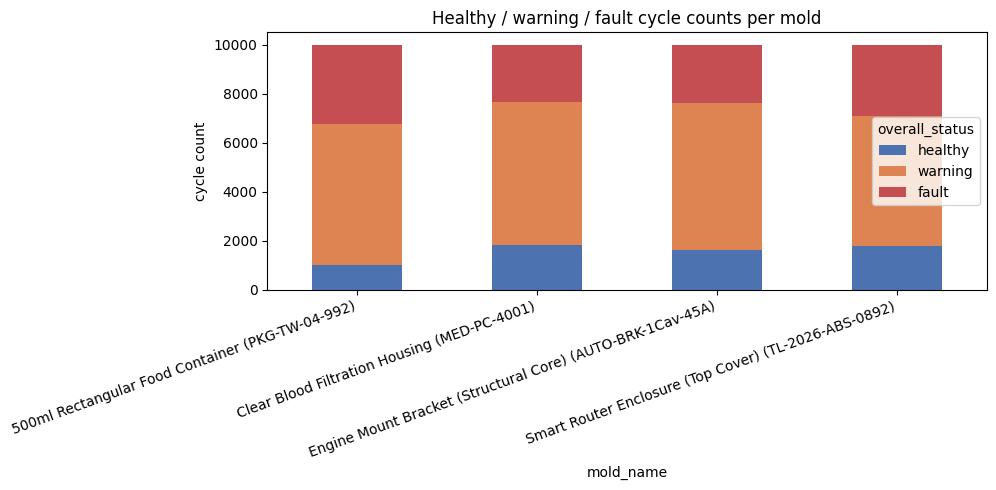

In [23]:
mold_status[order].plot(kind='bar', stacked=True, figsize=(10, 5),
                         color=['#4C72B0', '#DD8452', '#C44E52'])
plt.ylabel('cycle count')
plt.title('Healthy / warning / fault cycle counts per mold')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

In [24]:
from scipy.stats import chi2_contingency

contingency = mold_status[order]
chi2, p, dof, _ = chi2_contingency(contingency)
print(f'chi-square = {chi2:.1f}, dof = {dof}, p-value = {p:.2e}')
print(f"\nUnhealthy-cycle rate range across molds: {mold_status['unhealthy_rate'].min():.1%} - {mold_status['unhealthy_rate'].max():.1%}")

chi-square = 529.1, dof = 6, p-value = 4.59e-111

Unhealthy-cycle rate range across molds: 81.7% - 89.8%


**No — unhealthy-cycle counts are close but not equal across molds.** Row counts are balanced (10,000 each), but the unhealthy share (warning + fault) ranges from roughly 82% to 90% depending on mold, and the chi-square test confirms this difference is statistically significant, not just noise. The *500ml Rectangular Food Container* mold has the highest fault rate specifically, while the others are closer to each other. When splitting train/val/test by mold or evaluating per-mold performance, keep this imbalance in mind — a model validated mostly on the lower-fault-rate molds could look better than it would on the highest-fault-rate one.

## 10. Summary — is this dataset okay for the project?

**What's good:**
- Clean: no missing values, no duplicate rows, contiguous `cycle_number` per mold.
- Perfectly balanced across molds/materials (10,000 cycles each) — easy to reason about and split.
- Component states carry real, physically-sensible signal: e.g. `hopper_temp` is the top driver of `Hopper_State`, `H1/H2/H3` + `nozzle_temp` drive `Barrel_Heater_State`, and screw-related fields (`back_pressure`, `decompression_distance`, `shot_weight`, `screw_rpm`) drive `Screw_State`. Shallow-tree train accuracy of ~0.78-0.90 per target means the labels aren't trivially leaking from one column, nor are they pure noise.
- Same 9 target columns, same 0/1/2 encoding, and mostly the same process-parameter naming as `injection_molding_predictive_maintenance.csv`, so it's a drop-in fit for the existing feature-engineering / anomaly-detection / supervised pipeline with minimal changes.

**What to watch out for before reusing the existing pipeline as-is:**
- **No `mold_id` column.** `maintenance_model_building.ipynb` sorts and groups by `mold_id` for the split and one-hot-encodes it as a feature. You'll need to derive an id from `mold_name` (e.g. `df['mold_name'].astype('category').cat.codes`) or adapt those cells to group by `mold_name` directly.
- **Schema drift vs. the old file**: no `max_inj_pressure` / `normal_inj_pressure` / `inj_time_limit` (there's a single `actual_inj_pressure` instead), `holding_pressure` is now 3 stage columns instead of `holding_pressure` + `total_hold_time`, and `plasticizing_time`, `mould_open_time`, `mould_close_time`, `clamp_open_position`, `clamp_close_position`, `cushion_position` are all missing. Any feature-engineering step referencing those columns by name will break and needs updating.
- **Only ~15-16% fully-healthy rows** (vs. a much larger healthy share in the old file — check the printed comparison in section 5). The current anomaly-detection stage trains only on fully-healthy rows (`X_train_healthy`), so with 40,000 total rows you'd still have several thousand healthy rows to fit on, but noticeably fewer than before — worth re-checking that Isolation Forest/ECOD/COPOD/LOF/Autoencoder still fit and threshold-tune stably at this smaller healthy-set size.
- **`total_cycle_time` does not mark unhealthy cycles** (see section 8) — if anything, faulty cycles run slightly *faster* on average, not slower. So cycle time by itself is not a usable proxy/feature for detecting a fault.
- **Unhealthy-cycle rate is not identical across molds** (see section 9) — it ranges ~82-90% depending on mold, so a model needs to see all 4 molds rather than assuming the fault rate generalizes uniformly.
- Only 4 molds/materials here (same as the old file), so this doesn't add mold/material diversity — it looks like a smaller companion or replacement set rather than an expansion.

**Recommendation:** it's usable, but treat it as a *related, not identical* schema. Either (a) keep it as a separate, smaller validation dataset to sanity-check model generalisation across a slightly different simulation, or (b) if you intend to replace the old file, update the `mold_id` handling and any hard-coded column lists (`temp_pressure`, holding-pressure fields, etc.) in `maintenance_model_building.ipynb` before rerunning the pipeline on it.